## 1. Hidden Markov Model (HMM)
A Hidden Markov Model (HMM) is a statistical model used to predict sequences of unobservable (hidden) states based on a sequence of observable data. \
We aim to identify the **Market Regime** (hidden state) from **Macro Data** (observable data) and make informative investment decision on market index etf SPY.

Let $Z_t \in \{0,1,\dots,K-1\}$ be the hidden state, and let $X_t \in \{ \text{log\_return}_t, \text{credit\_spread}_t, \text{VRP}_t \}$ be the observable data.

1. **Hidden State $Z_t$** \
Concept: Transition Probability. It tells us the chances of switching hidden states, which follows Markov Property (Current state only depends on previous state).
$$
P(Z_t=j\mid Z_{t-1}=i)=A_{ij},\qquad
A=\begin{bmatrix}
a_{0,0}&\cdots&a_{0,K-1}\\
\vdots&\ddots&\vdots\\
a_{K-1,0}&\cdots&a_{K-1,K-1}
\end{bmatrix}.
$$

2. **Observable Data $X_t$** \
Concept: Emission Probability. It tells us the chances of emission probability of observable data given hidden states, which follows Gaussian Distribution with mean $\mu_k$ and variance $\Sigma_k$.
$$
P(X_t\mid Z_t=k)=\mathcal N(X_t\mid \mu_k,\Sigma_k).
$$

3. **Initial distribution $\pi$**  \
Concept: Probability of $Z_{t=1} \in \{0,1,\dots,K-1\}$ stay at each state initially.
$$
\pi=
\begin{bmatrix}
\pi_0\\
\vdots\\
\pi_{K-1}
\end{bmatrix},
\qquad
\pi=A^\top \pi,
\qquad
\sum_{k=0}^{K-1}\pi_k=1.
$$

4. **Joint probability $P(X_{1:T},Z_{1:T})$** \
Concept: This will be used as calculation of a) Data Likelihood Function in Goal 1 b) Probability of sequence of hidden states in Goal 2.
$$
\begin{aligned}
P(X_{1:T},Z_{1:T})
&=
\underbrace{P(Z_1)}_{\pi_{Z_1}}
\cdot
\underbrace{P(X_1 \mid Z_1)}_{\text{Emission at } t=1}
\cdot
\prod_{t=2}^{T}
\underbrace{P(Z_t \mid Z_{t-1})}_{A_{Z_{t-1}, Z_t}}
\cdot
\underbrace{P(X_t \mid Z_t)}_{\text{Emission at } t}
\\
&=
\pi_{Z_1}\,P(X_1\mid Z_1)\,
\prod_{t=2}^{T} A_{Z_{t-1},Z_t}\,P(X_t\mid Z_t).
\end{aligned}
$$


---

#### Goal 1: Learn parameters $\hat\theta=\{\pi,A,\mu_k,\Sigma_k\}$

To estimate the best parameter $\hat\theta$, we need to maximize the Likelihood function $P(X_{1:T}\mid \theta)$:
$$
\hat\theta=\arg\max_{\theta} P(X_{1:T}\mid \theta)
=
\arg\max_{\theta}\sum_{Z_{1:T}} P(X_{1:T},Z_{1:T}\mid \theta).
$$
$$
P(X_{1:T},Z_{1:T}\mid\theta)
=
\pi_{Z_1}\prod_{t=2}^{T}A_{Z_{t-1},Z_t}\prod_{t=1}^{T}b_{Z_t}(X_t),
\qquad
b_k(x)=\mathcal N(x\mid\mu_k,\Sigma_k).
$$
We obtain the best parameters $\hat\theta$ by **Baum–Welch (EM) Algorithm**\
(Wikipedia source: https://en.wikipedia.org/wiki/Baum%E2%80%93Welch_algorithm)

1. **E-step (Forward–Backward)** \
Concept: We initialize the parameters with a random guess, then compute how likely each state/transition was for every day in the history \
**Foward-Backward Algorithm**: It computes the probability of hidden state at anytime $\gamma_t(k)$ by combining forward probabilities (past evidence) and backward probabilities (future evidence) \
(Wikipedia source: https://en.wikipedia.org/wiki/Forward%E2%80%93backward_algorithm)
$$
\alpha_1(k)=\pi_k b_k(X_1),\qquad
\alpha_{t+1}(j)=\Big(\sum_{i=0}^{K-1}\alpha_t(i)A_{ij}\Big)\,b_j(X_{t+1}).
$$
$$
\beta_T(k)=1,\qquad
\beta_t(i)=\sum_{j=0}^{K-1}A_{ij}\,b_j(X_{t+1})\,\beta_{t+1}(j).
$$
$$
\gamma_t(k)=P(Z_t=k\mid X_{1:T})
=
\frac{\alpha_t(k)\beta_t(k)}{\sum_{\ell=0}^{K-1}\alpha_t(\ell)\beta_t(\ell)}.
$$
$$
\xi_t(i,j)=P(Z_t=i,Z_{t+1}=j\mid X_{1:T})
=
\frac{\alpha_t(i)A_{ij}b_j(X_{t+1})\beta_{t+1}(j)}
{\sum_{p=0}^{K-1}\sum_{q=0}^{K-1}\alpha_t(p)A_{pq}b_q(X_{t+1})\beta_{t+1}(q)}.
$$

2. **M-step (Update Parameters)** \
Concept: We update parameters and calculate likelihood function. We repeat this until the likelihood function is maximized.
$$
\pi_k^{new}=\gamma_1(k),
\qquad
A_{ij}^{new}=\frac{\sum_{t=1}^{T-1}\xi_t(i,j)}{\sum_{t=1}^{T-1}\gamma_t(i)}.
$$
$$
\mu_k^{new}=\frac{\sum_{t=1}^{T}\gamma_t(k)X_t}{\sum_{t=1}^{T}\gamma_t(k)}.
$$
$$
\Sigma_k^{new}
=
\frac{\sum_{t=1}^{T}\gamma_t(k)(X_t-\mu_k^{new})(X_t-\mu_k^{new})^\top}
{\sum_{t=1}^{T}\gamma_t(k)}.
$$

---

#### Goal 2: Decoding States $\hat{Z}_{1:T}$
Concept: Once the model parameter is trained, we identify the most likely sequence of hidden states by looking at the whole timeline.
$$
\hat{Z}_{1:T} = \operatorname*{argmax}_{Z_{1:T}} P(Z_{1:T} \mid X_{1:T}, \hat{\theta}) = \operatorname*{argmax}_{Z_{1:T}} \frac{P(X_{1:T}, Z_{1:T} \mid \hat{\theta})}{P(X_{1:T} \mid \hat{\theta})} = \operatorname*{argmax}_{Z_{1:T}} P(X_{1:T}, Z_{1:T} \mid \hat{\theta})
$$
*Solved via the **Viterbi Algorithm**. (Wikipedia source: https://en.wikipedia.org/wiki/Viterbi_algorithm)*

---

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')


def data_preparation(tickers, period="100y", interval="1d", ret_window=21, mean_window=252):
    main_df = yf.download(tickers[0], period=period, interval=interval, auto_adjust=True, progress=False)
    vix = yf.download("^VIX", period=period, interval=interval, auto_adjust=True, progress=False)["Close"]
    main_oo = yf.download(tickers[0], period=period, interval=interval, auto_adjust=True, progress=False)["Close"].pct_change().shift(-1)  # For calculating returns entry position at t

    main = main_df["Close"]
    main.columns    = [f"{tickers[0]}_Close"]
    main_oo.columns = [f"{tickers[0]}_oo"]
    main[f"{tickers[0]}_ret"] = np.log(main[f"{tickers[0]}_Close"] / main[f"{tickers[0]}_Close"].shift(1))
    main[f"{tickers[0]}_rolling_ret"] = main[f"{tickers[0]}_ret"].rolling(window=ret_window).mean()
    main[f"{tickers[0]}_rv"] = main[f"{tickers[0]}_ret"].rolling(window=ret_window).std()

    credit_spread = pd.DataFrame()
    credit_spread["lqd"] = yf.download("LQD", period=period, auto_adjust=True, progress=False)["Close"]
    credit_spread["ief"] = yf.download("IEF", period=period, auto_adjust=True, progress=False)["Close"]
    credit_spread["credit_spread"] = (credit_spread["ief"] / credit_spread["lqd"])
    credit_spread["credit_spread"] = ((credit_spread["credit_spread"] - credit_spread["credit_spread"].rolling(window=mean_window).mean()) / credit_spread["credit_spread"].rolling(window=mean_window).std())

    vix.columns = ["vix"]
    vix["vrp"] = vix["vix"] - main[f"{tickers[0]}_rv"]
    vix["vrp"] = ((vix["vrp"] - vix["vrp"].rolling(window=mean_window).mean()) / vix["vrp"].rolling(window=mean_window).std())

    openinsider_raw = pd.read_csv("open_insider_raw.csv")
    openinsider_raw["Date"] = pd.to_datetime(openinsider_raw["Date"])
    openinsider_raw.set_index("Date", inplace=True)
    openinsider = pd.DataFrame(openinsider_raw["Purchases"] / openinsider_raw["Sales"])
    openinsider.columns = ["PS_ratio"]
    openinsider["PS_ratio"] = ((openinsider["PS_ratio"] - openinsider["PS_ratio"].rolling(window=mean_window).mean()) / openinsider["PS_ratio"].rolling(window=mean_window).std())
    openinsider["PS_ratio"] = openinsider["PS_ratio"].shift(1)

    df = pd.concat([main, main_oo, credit_spread["credit_spread"], vix["vrp"], openinsider], axis=1, join="inner").dropna()
    return df


def hmm_weight(tickers, df, n_states=3, past_data_size=int(252*10), n_iters=200, accumulation_size=1, ps_period=30, ps_target=3.5, ps_gap=5, short_ret_target=-0.002, long_ret_target=0.00, show_print=True):
    weight = {}
    accumulation_number = 0
    weight_list = np.full((len(df), len(tickers)), np.nan)
    X_raw_ret = df[[f"{tickers[0]}_ret", "credit_spread", "vrp"]]

    signal_returns = {"stressed_normal_buy": [], "stressed_ps_hold": [], "stressed_ps_buy": [], "stressed_sell": [], "stressed_no_action": [], "calm_normal_buy": [], "calm_no_action": []}
    for t in range(past_data_size, len(df)):
        X_raw_trains = X_raw_ret.iloc[t-past_data_size+1:t+1]
        # Training Day 
        if accumulation_number == 0: 
            scaler = StandardScaler()
            X_trains = scaler.fit_transform(X_raw_trains)
            model = GaussianHMM(n_components=n_states, covariance_type="full", n_iter=n_iters, tol=1e-3, min_covar=1e-3, random_state=42).fit(X_trains)
        # Non-Training Day
        else:
            X_trains = scaler.transform(X_raw_trains)
                
        next_state = model.predict(X_trains)[-1]

        if not np.isnan(weight_list[t]).any():
            weight_list[t] = weight_list[t]

        # Predicted Stressed state
        elif ((model.means_[next_state, 0] < 0) or (next_state == np.argmin(model.means_[:, 0]))) and ((next_state == np.argmax(model.means_[:, 1])) or (next_state == np.argmax(model.means_[:, 2]))):

            # Openinsider in stressed state: Buy signal
            if (df[f"{tickers[0]}_rolling_ret"].iloc[t] < short_ret_target) and (df["PS_ratio"].iloc[t] > ps_target) and (t + ps_gap + ps_period <= len(df)):
                weight_list[t : t + ps_gap] = [0]
                weight_list[t + ps_gap : t + ps_gap + ps_period] = [1]
                if show_print: print(f"(PS signal for {ps_period} days)")
                signal_returns["stressed_ps_hold"].append(df[f"{tickers[0]}_oo"].iloc[t : t + ps_gap])
                signal_returns["stressed_ps_buy"].append(df[f"{tickers[0]}_oo"].iloc[t + ps_gap : t + ps_gap + ps_period])
            
            # Real Stressed state: Sell signal
            elif (df[f"{tickers[0]}_rolling_ret"].iloc[t] < short_ret_target) and (model.means_[next_state, 0] < 0) and (next_state == np.argmin(model.means_[:, 0])):
                weight_list[t] = [-1]
                signal_returns["stressed_sell"].append(-df[f"{tickers[0]}_oo"].iloc[t])
            
            # Normal state: Buy signal
            elif (df[f"{tickers[0]}_rolling_ret"].iloc[t] > long_ret_target):
                weight_list[t] = [1]
                signal_returns["stressed_normal_buy"].append(df[f"{tickers[0]}_oo"].iloc[t])
            
            # Uncertain: No signal
            else:
                weight_list[t] = [0]
                signal_returns["stressed_no_action"].append(df[f"{tickers[0]}_oo"].iloc[t])

        # Predicted Calm State
        else:

            # Starting of Stressed state: No Buy signal
            if (df[f"{tickers[0]}_rolling_ret"].iloc[t] < short_ret_target):
                weight_list[t] = [0]
                signal_returns["calm_no_action"].append(df[f"{tickers[0]}_oo"].iloc[t])
            
            # Normal state: Buy signal
            else:
                weight_list[t] = [1]
                signal_returns["calm_normal_buy"].append(df[f"{tickers[0]}_oo"].iloc[t])
        if show_print: print("weight at ", df.index[t].date(), ": ", weight_list[t])
        
        accumulation_number += 1
        if accumulation_number == accumulation_size: 
            accumulation_number = 0;
    
    for ticker in tickers:
        weight[ticker] = pd.Series(weight_list[:, tickers.index(ticker)], index=df.index)
    df["port_oo"] = df[f"{tickers[0]}_oo"] * weight[tickers[0]]
    ret_df = df[[f"{tickers[0]}_oo", "port_oo"]].iloc[past_data_size:]
    cash_proportion = (weight_list[past_data_size:].sum(axis=1) == 0).mean()
    print(f"Cash Proportion: {cash_proportion:.2%}\n")

    summary_signal_df = pd.DataFrame({
        "mean": {
            signal_name: np.mean(signal_values) if len(signal_values) > 0 else np.nan
            for signal_name, signal_values in signal_returns.items()
        },
        "std": {
            signal_name: np.std(signal_values) if len(signal_values) > 0 else np.nan
            for signal_name, signal_values in signal_returns.items()
        },
        "Frequency": {
            signal_name: len(signal_values)
            for signal_name, signal_values in signal_returns.items()
        }
    })
    display(summary_signal_df)
    plt.figure(figsize=(12, 6))
    for signal_name, signal_values in signal_returns.items():
        if signal_values: plt.hist(signal_values, bins=30, alpha=0.5, label=signal_name)
    plt.title("Signal Return Histogram"); plt.xlabel("Return"); plt.ylabel("Frequency")
    plt.legend(); plt.grid(True)
    plt.show()

    return ret_df


def overall_return_matrics(returns, window=252):
    annual_mean = returns.mean() * window
    annual_std = returns.std() * np.sqrt(window)
    annual_down_std = np.sqrt(np.mean(np.minimum(0.0, returns)**2)) * np.sqrt(window)
    annual_sharpe = annual_mean / annual_std
    annual_sortino = annual_mean / annual_down_std

    rolling_mean = returns.rolling(window).mean()
    rolling_std = returns.rolling(window).std()
    rolling_sharpe = np.sqrt(window) * rolling_mean / rolling_std

    cumprod = (1 + returns).cumprod()
    cumprod_max = cumprod.cummax()
    dd = (cumprod - cumprod_max) / cumprod_max
    max_dd = dd.min()

    return cumprod, rolling_mean, rolling_std, rolling_sharpe, annual_mean, annual_std, annual_sharpe, annual_sortino, max_dd
        

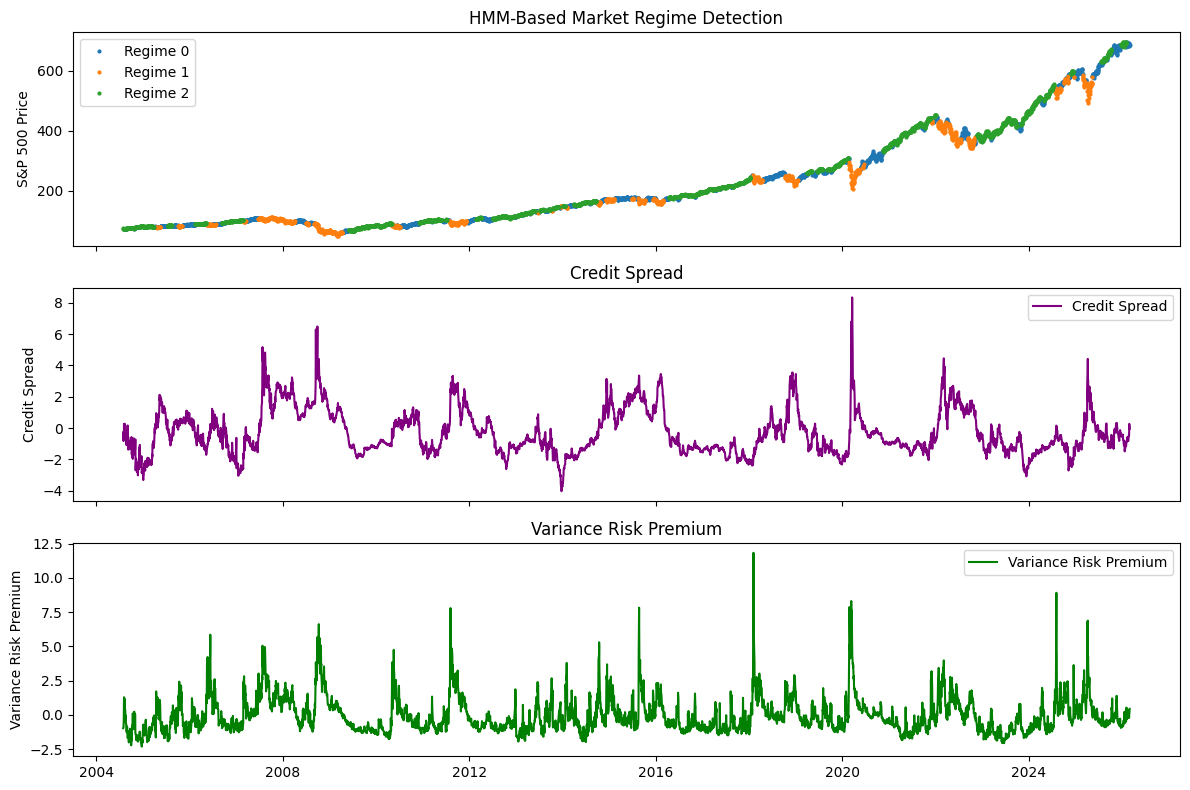

In [56]:
yr = 10
n_state = 3
tickers = ["SPY"]

df = data_preparation(tickers)
X_raw_ret = df[[f"{tickers[0]}_ret", "credit_spread", "vrp"]]
model = GaussianHMM(n_components=n_state, covariance_type="full", n_iter=200, random_state=42)
model.fit(X_raw_ret.values)
states = model.predict(X_raw_ret.values)

# Regime Graph
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
aligned_close = df[f"{tickers[0]}_Close"].reindex(df.index)
for state in range(n_state):
    mask = (states == state)
    ax1.plot(df.index[mask], aligned_close.loc[df.index[mask]], ".", markersize=4, label=f"Regime {state}")

ax1.set_title("HMM-Based Market Regime Detection")
ax1.set_ylabel("S&P 500 Price")
ax1.legend()

ax2.plot(df.index, df["credit_spread"], color="purple", label="Credit Spread")
ax2.set_ylabel("Credit Spread")
ax2.set_title("Credit Spread")
ax2.legend()

ax3.plot(df.index, df["vrp"], color="green", label="Variance Risk Premium")
ax3.set_ylabel("Variance Risk Premium")
ax3.set_title("Variance Risk Premium")
ax3.legend()

plt.tight_layout()
plt.show()


weight at  2014-09-09 :  [1.]
weight at  2014-09-10 :  [1.]
weight at  2014-09-11 :  [1.]
weight at  2014-09-12 :  [1.]
weight at  2014-09-15 :  [1.]
weight at  2014-09-16 :  [1.]
weight at  2014-09-17 :  [1.]
weight at  2014-09-18 :  [1.]
weight at  2014-09-19 :  [1.]
weight at  2014-09-22 :  [1.]
weight at  2014-09-23 :  [1.]
weight at  2014-09-24 :  [1.]
weight at  2014-09-25 :  [1.]
weight at  2014-09-26 :  [1.]
weight at  2014-09-29 :  [0.]
weight at  2014-09-30 :  [1.]
weight at  2014-10-01 :  [1.]
weight at  2014-10-02 :  [1.]
weight at  2014-10-03 :  [1.]
weight at  2014-10-06 :  [1.]
weight at  2014-10-07 :  [0.]
weight at  2014-10-08 :  [0.]
weight at  2014-10-09 :  [0.]
weight at  2014-10-10 :  [-1.]
weight at  2014-10-14 :  [-1.]
weight at  2014-10-15 :  [-1.]
weight at  2014-10-16 :  [-1.]
weight at  2014-10-17 :  [-1.]
weight at  2014-10-20 :  [-1.]
weight at  2014-10-21 :  [0.]
weight at  2014-10-22 :  [0.]
weight at  2014-10-23 :  [0.]
weight at  2014-10-24 :  [1.]
weig

,mean,std,Frequency
stressed_normal_buy,0.000262,0.010213,139
stressed_ps_hold,0.000471,0.035730,9
stressed_ps_buy,0.001596,0.016360,9
stressed_sell,-0.000023,0.020234,97
stressed_no_action,-0.000712,0.013693,140
calm_normal_buy,0.000542,0.007898,2104
calm_no_action,0.000787,0.012523,59


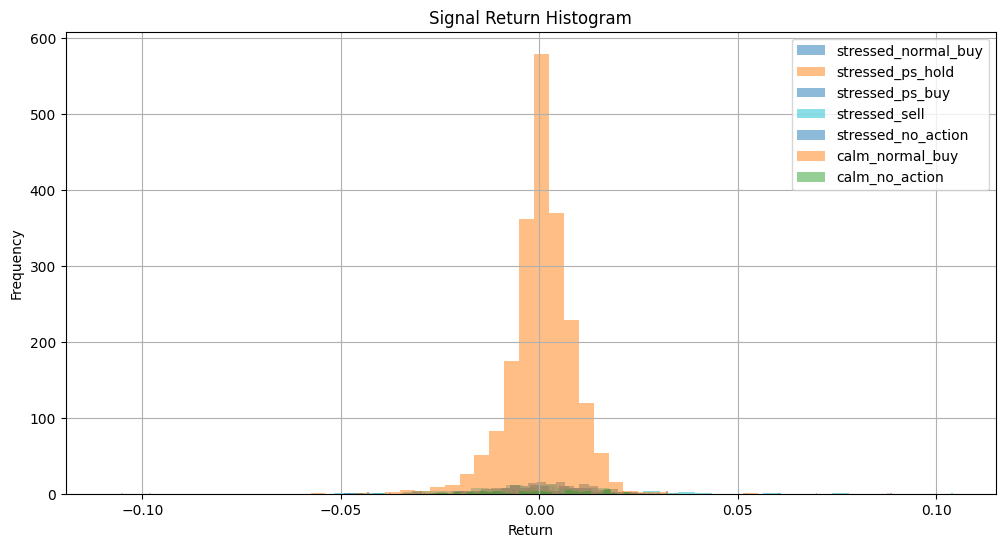

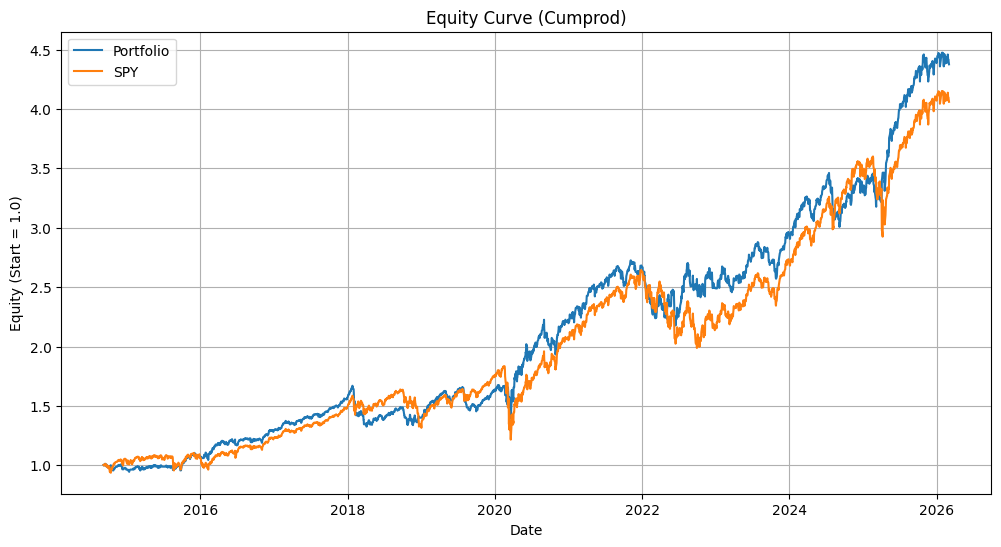

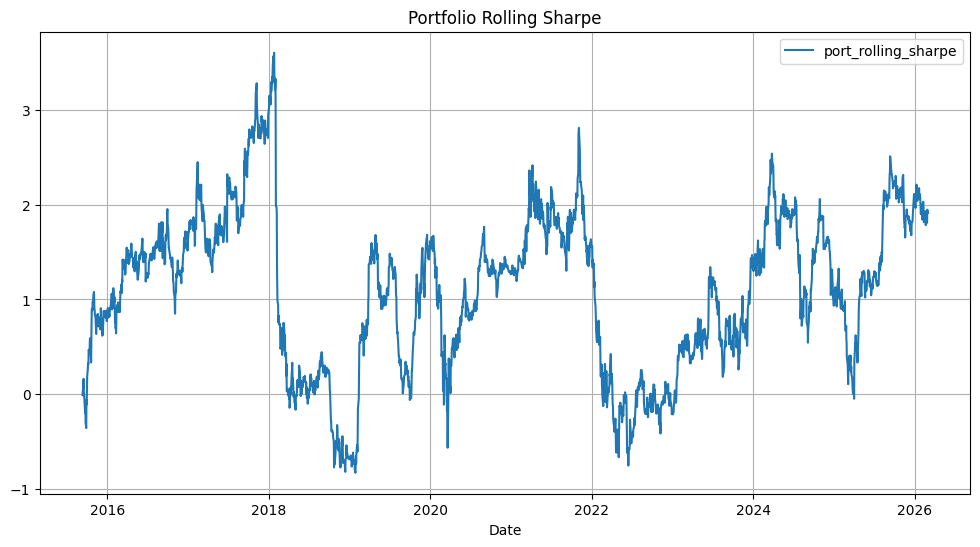

,mean,std,sharpe,sortino,max_dd
Portfolio,0.141748,0.151002,0.938716,1.363749,-0.206043
SPY,0.139309,0.176139,0.790904,1.109879,-0.337173


In [57]:
yr = 10
tickers = ["SPY"]
df = data_preparation(tickers)
ret_df = hmm_weight(tickers, df, past_data_size=int(252*yr))
cumprods, rolling_means, rolling_stds, rolling_sharpes, tot_means, tot_stds, tot_sharpes, tot_sortinos, max_dds = {}, {}, {}, {}, {}, {}, {}, {}, {}
port_cumprod, port_rolling_mean, port_rolling_std, port_rolling_sharpe, port_tot_mean, port_tot_std, port_tot_sharpe, port_tot_sortino, port_max_dd = overall_return_matrics(ret_df["port_oo"])
for ticker in tickers:
    cumprods[ticker], rolling_means[ticker], rolling_stds[ticker], rolling_sharpes[ticker], tot_means[ticker], tot_stds[ticker], tot_sharpes[ticker], tot_sortinos[ticker], max_dds[ticker] = overall_return_matrics(ret_df[f"{ticker}_oo"])

# -----------------------------
# 1) Equity curve (cumprod)
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(port_cumprod.index, port_cumprod.values, label="Portfolio")
for ticker in tickers:
    plt.plot(cumprods[ticker].index, cumprods[ticker].values, label=ticker)
plt.title("Equity Curve (Cumprod)")
plt.xlabel("Date")
plt.ylabel("Equity (Start = 1.0)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 2) Portfolio rolling sharpe
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(port_rolling_sharpe.index, port_rolling_sharpe.values, label="port_rolling_sharpe")
plt.title("Portfolio Rolling Sharpe")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 3) Summary table: mean / std / sharpe / max_dd
# -----------------------------
summary_df = pd.DataFrame({
        "mean":   [port_tot_mean]   + [tot_means[ticker]   for ticker in tickers],
        "std":    [port_tot_std]    + [tot_stds[ticker]    for ticker in tickers],
        "sharpe": [port_tot_sharpe] + [tot_sharpes[ticker] for ticker in tickers],
        "sortino":[port_tot_sortino]+ [tot_sortinos[ticker]for ticker in tickers],
        "max_dd": [port_max_dd]     + [max_dds[ticker]     for ticker in tickers],
    }, index=["Portfolio"] + list(tickers),
)

display(summary_df)
